# Artifact-Based Plotting Demo

The following cells demonstrate the new artifact-based plotting workflow:
1. **Generate data** using scripts (one-time)
2. **Plot from saved artifacts** (fast, reproducible)

In [ ]:
# Setup: autoreload for development (optional)
try:
    from IPython import get_ipython
    ipython = get_ipython()
    if ipython:
        ipython.run_line_magic('load_ext', 'autoreload')
        ipython.run_line_magic('autoreload', '2')
except Exception:
    pass  # Autoreload not available, continue without it

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Reload modules to pick up changes
import importlib
import spins_sdp.sdp
import spins_sdp.pauli
importlib.reload(spins_sdp.sdp)
importlib.reload(spins_sdp.pauli)

import plots
from spins_sdp.scripts import exact_ground_energy, npa_energy_lb
from spins_sdp.utils import iter_result_runs, format_result_runs_table

## Step 1: Generate Artifacts (Run Once)

These scripts compute exact ground energies and SDP lower bounds, saving results to disk.
Re-running with `--resume` only computes missing N values.

In [20]:
# Generate exact ground energies for the Ising model
exact_ground_energy.main([
    "--model", "heisenberg",
    "--N-min", "9",
    "--N-max", "15",
    #"--J", "1", "--h", "0.7", "--k", "0.3",
    "--boundary", "periodic",
    "--resume",
])

Wrote results to: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/spins_sdp/results/spin_exact_ground_energy/v1/aadfb1b072afee7f


0

In [4]:
# Generate SDP lower bounds (with all symmetries for Heisenberg)
npa_energy_lb.main([
    "--model", "heisenberg",
    "--basis", "heisenberg_simple",
    #"--npa-level", "2",
    "--N-min", "2",
    "--N-max", "15",
    "--boundary", "periodic",
    "--resume",
    "--use-all-symmetries",  # Enable all symmetries for Heisenberg
])

Moment relaxation sweep:   0%|          | 0/14 [00:00<?, ?it/s, N=2, done=0, total=14]

Moment relaxation sweep: 100%|██████████| 14/14 [02:16<00:00,  9.72s/it, N=15, done=13, total=14]

Wrote results to: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/spins_sdp/results/spin_moment_energy_lb/v1/ba7bdcff68936d5d


0

## Step 2: List Available Runs

Use the `list_runs` utilities to see what artifacts are stored.

In [7]:
# View stored exact ground energy runs
from spins_sdp.utils import list_exact_runs
list_exact_runs()

artifact               v   hash             max_N updated_at           model          boundary  basis              npa_k 
-------------------------------------------------------------------------------------------------------------------------
spin_exact_ground_ene… v1  f0e28cf3d0e38590 12    2026-02-09T12:36:37Z ising          periodic                           


In [ ]:
# View stored NPA lower bound runs
from spins_sdp.utils import list_lb_runs
list_lb_runs()

: 

## Step 3: Plot from Artifacts

The artifact-based plotting functions load data from saved runs.

### Comparing Exact vs SDP Lower Bound

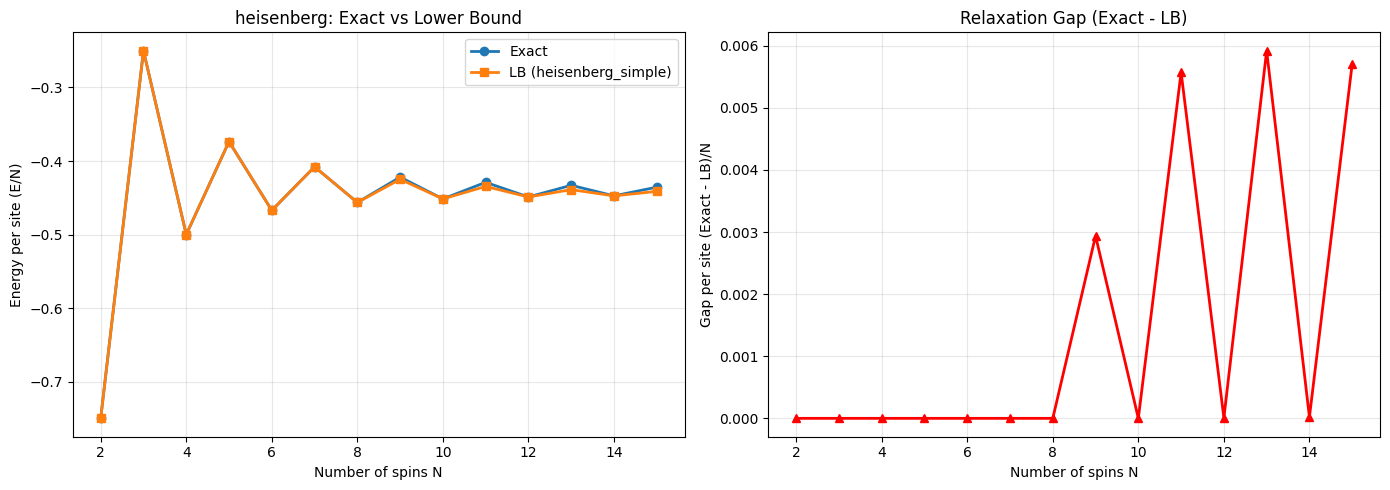

In [5]:
# Plot exact vs NPA lower bound for the Ising model
# Uses parameter-based lookup to find matching artifacts
from plots import plot_exact_vs_lb

_ = plot_exact_vs_lb(
    model="heisenberg",
    model_params={}, #{"J": 1.0, "h": 0.7, "k": 0.3},
    boundary="periodic",
    lb_basis="heisenberg_simple",
    per_site=True,
)

### Utility Plots (Computed On-the-Fly)

Some plotting utilities perform quick computations directly without needing stored artifacts.

In [ ]:
# NPA basis size heatmap: visualize how basis size scales with N and NPA level
from plots import npa_basis_size_heatmap

_ = npa_basis_size_heatmap(N_max=20, npa_level_max=2)

In [ ]:
# Compare basis sizes across different methods
from plots import plot_basis_size_comparison

_ = plot_basis_size_comparison(
    N_values=range(2, 10),
    npa_levels=[1, 2],
    include_paper_basis=True,
)

## Runtime Comparison

Compare solve times between exact diagonalization and SDP relaxation.

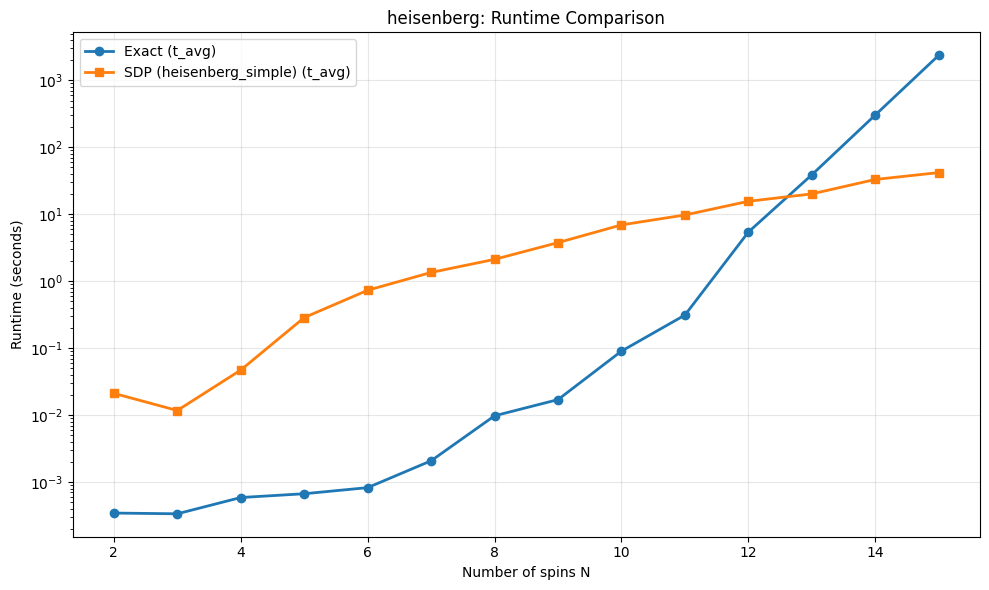

In [6]:
# Plot runtime comparison: Exact diagonalization vs SDP
from plots import plot_runtime_comparison

_ = plot_runtime_comparison(
    model="heisenberg",
    model_params={},#{"J": 1.0, "h": 0.7, "k": 0.3},
    boundary="periodic",
    lb_basis="heisenberg_simple",
    npa_levels=[2],
    use="t_avg",
    logy=True,
)

## Heisenberg-J₂ Sweep Demo

The `plot_heisenberg_j2_sweep` function plots energy vs J₂ coupling for a fixed N.
First, we need to generate the artifacts for multiple J₂ values.

In [13]:
# Generate Heisenberg-J2 exact ground energies for several J2 values (N=4, small for demo)
J2_values = [0.0, 0.3, 0.5, 0.7, 1.0, 1.3, 1.5]

for J2 in J2_values:
    exact_ground_energy.main([
        "--model", "heisenberg_j2",
        "--N-min", "4",
        "--N-max", "4",
        "--J2", str(J2),
        "--boundary", "periodic",
        "--resume",
    ])

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\2b91e99e24e6095a
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\af44b6816fc66636
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\04c74a7ae54a1815
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\d5681820b0b0e7ca
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\8b64f864e20d738e
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\b600d698458f7bca
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\b452107f935791bc


In [ ]:
# Generate SDP lower bounds for the Heisenberg-J2 model (with all symmetries)
# Using heisenberg_j2_weak basis for J2 <= 1.0, heisenberg_j2_strong for J2 > 1.0

for J2 in J2_values:
    basis = "heisenberg_j2_weak" if J2 <= 1.0 else "heisenberg_j2_strong"
    npa_energy_lb.main([
        "--model", "heisenberg_j2",
        "--basis", basis,
        "--N-min", "4",
        "--N-max", "4",
        "--J2", str(J2),
        "--boundary", "periodic",
        "--resume",
        "--use-all-symmetries",  # Enable all symmetries for Heisenberg
    ])

Moment relaxation sweep: 100%|██████████| 1/1 [00:00<00:00, 11.25it/s, N=4, done=0, total=1]


Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\846e9dcc176708f3


Moment relaxation sweep: 100%|██████████| 1/1 [00:00<00:00, 12.33it/s, N=4, done=0, total=1]


Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\465679cc0e36d92c


Moment relaxation sweep: 100%|██████████| 1/1 [00:00<00:00, 11.89it/s, N=4, done=0, total=1]


...

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\d0b4419fa6b6e0d3


Moment relaxation sweep: 100%|██████████| 1/1 [00:00<00:00, 18.54it/s, N=4, done=0, total=1]


Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\15ae3def069ac7a7


Moment relaxation sweep: 100%|██████████| 1/1 [00:00<00:00, 21.53it/s, N=4, done=0, total=1]

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\8f8044f3ffa88392


In [ ]:
# Plot Heisenberg-J2 sweep
from plots import plot_heisenberg_j2_sweep

_ = plot_heisenberg_j2_sweep(
    N=4,
    J2_values=J2_values,
    boundary="periodic",
    per_site=True,
)

## Summary (Exact & SDP Artifacts)

General workflow for exact/SDP results:

1. **Generate Artifacts** – Run scripts (`exact_ground_energy`, `npa_energy_lb`) to compute and save results with `--resume` for incremental updates.
2. **List Runs** – Use `list_exact_runs()` and `list_lb_runs()` to inspect stored data.
3. **Plot from Artifacts** – Call plotting functions to visualize results without recomputation:
   - `plot_exact_vs_lb()` – Compare exact vs SDP lower bound
   - `plot_runtime_comparison()` – Compare solve times
   - `plot_heisenberg_j2_sweep()` – Energy vs J₂ coupling
4. **Utility Plots** – Quick on-the-fly visualizations:
   - `npa_basis_size_heatmap()` – Heatmap of basis sizes
   - `plot_basis_size_comparison()` – Compare basis methods

---

# Optimization Sweep Demo

This section demonstrates the **optimization sweep** functionality, which uses the optimization package to find optimal subsets of monomials to add to a starting NPA basis.

## The Problem

Given:
- A **starting set** of monomials (e.g., NPA level 1)
- An **adding set** of candidate monomials (difference between NPA level 2 and level 1)
- A **Hamiltonian** to minimize

We want to find which **k monomials** from the adding set give the best SDP lower bound.

This is a combinatorial optimization problem with $\binom{L}{k}$ possible choices, where $L = |\text{adding set}|$.

## Symmetry Options

For the **Heisenberg model**, we can exploit multiple symmetries to speed up SDP solves:

| Flag | Effect |
|------|--------|
| `--use-real-operator` | Restrict to real moments (Heisenberg H is real) |
| `--use-rotation` | Block-diagonalize by Pauli signature |
| `--use-sign-symmetry` | Zero out sign-variant moments |
| `--use-permutation` | Group by X↔Y↔Z relabeling |
| `--use-translation` | Group by cyclic translation (periodic BC) |
| `--use-mirror` | Group by spatial reflection |
| `--use-all-symmetries` | Enable all of the above |

Using `--use-all-symmetries` gives exponential speedups for Heisenberg chains.

## Step 1: Run an Optimization Sweep

The `optimization_sweep` script runs Monte Carlo optimization for multiple values of k (number of monomials to add) and multiple random seeds, saving all results to disk.

### CLI Usage

```bash
# Basic usage with simulated annealing
python -m spins_sdp.scripts.optimization_sweep \
    --model heisenberg --N 4 --boundary periodic \
    --start-level 1 --end-level 2 \
    --method sa --sa-steps 50 \
    --ks 0 1 2 3 4 5 \
    --seeds 42 43 44

# Or sweep k from 0 to k-max (inclusive)
python -m spins_sdp.scripts.optimization_sweep \
    --model heisenberg --N 4 --boundary periodic \
    --start-level 1 --end-level 2 \
    --method sa --sa-steps 50 \
    --k-max 10 --num-seeds 3
```

### Getting help (list all args)

To see all available command-line arguments (including `--method`-specific options), run:

```bash
python -m spins_sdp.scripts.optimization_sweep --help
# or
python -m spins_sdp.scripts.optimization_sweep -h
```

If you have multiple Python installations, make sure you’re using your project environment’s interpreter. In this repo that’s typically:

```bash
C:/.../code/SpinsSDP/.venv/Scripts/python.exe -m spins_sdp.scripts.optimization_sweep -h
```

### Programmatic Usage (in notebook)

In [1]:
# Run optimization sweep programmatically with all Heisenberg symmetries enabled
from spins_sdp.scripts import optimization_sweep

# Run a small sweep with full symmetry exploitation
# Tip: add "--force" if you want to recompute and re-print stats even if already cached.
optimization_sweep.main([
    "--model", "heisenberg",
    "--N", "10",
    "--boundary", "periodic",
    "--start-level", "1",
    "--end-level", "2",
    "--end-basis", "heisenberg_simple",
    "--method", "pt",
    "--pt-epochs", "1",
    "--pt-steps-per-epoch", "10",
    # "--method", "bo",
    # "--bo-n-init", "20",
    # "--bo-n-iter", "20",
    # "--bo-candidates-per-iter", "20",
    "--ks", "10", "20", "40", "80", "100", "150", "200", "250", "300", "350", "400",
    "--num-seeds", "5",
    "--use-all-symmetries",
    "--feedback",
])

Model: heisenberg, N=10, boundary=periodic, end_basis=heisenberg_simple
Starting set size: 31, Adding set size: 1485, Final set size: 1516
Feedback mode: ON (warm-start chaining across k values)
Total jobs requested: 55, Already in artifact: 0, To compute now: 55


Optimization sweep: 100%|██████████| 55/55 [14:12<00:00, 15.51s/it, k=400, seed=46]


Results saved to: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/spins_sdp/results/spin_optimization_sweep/v1/dea6756675dc56cb
Total runs in artifact: 55 (requested this call: 55, computed this call: 55)
Results saved to: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/spins_sdp/results/spin_optimization_sweep/v1/dea6756675dc56cb


0

## Step 2: List Available Optimization Runs

Use `list_optimization_runs()` to see what optimization sweeps are stored.

In [2]:
# List all optimization sweep runs
from plots import list_optimization_runs

runs = list_optimization_runs()

Hash               Model          N Method    L         k  Runs Updated             
--------------------------------------------------------------------------------
d281ed31b16b113d   heisenberg    10     pt  406   10..400    55 2026-02-09T13:20:58 
eaa617dbd2e9dec4   heisenberg    10 random  406   10..400   220 2026-02-09T13:30:30 
22789345a337f209   heisenberg    10     bo  405   10..400    55 2026-02-09T17:09:00 
61826619291e8b17   heisenberg    10     bo 20655   10..400    55 2026-02-09T15:25:56 
ccb9ea260ebbc6e1   heisenberg    10     pt 20656   10..400    55 2026-02-09T14:51:26 
a3019dc10ffb0081   heisenberg    10    rbm  405      2..6     6 2026-02-09T15:49:34 
87c75a62d96d2b80   heisenberg    10    rbm 20655    10..40    15 2026-02-09T15:57:19 
171af9d4638fce65   heisenberg    10    rbm  405   10..400    55 2026-02-09T17:35:45 
a2fe3aeb06739c9d   heisenberg    10     pt  405   10..400    55 2026-02-09T16:45:23 
6713b778763ea466   heisenberg    10     bo 1485   0..1485    39 20

## Step 3: Plot Optimization Results

### Main Plot: Lower Bound vs Number of Monomials

The primary visualization shows how the SDP lower bound improves as we add more monomials to the basis.

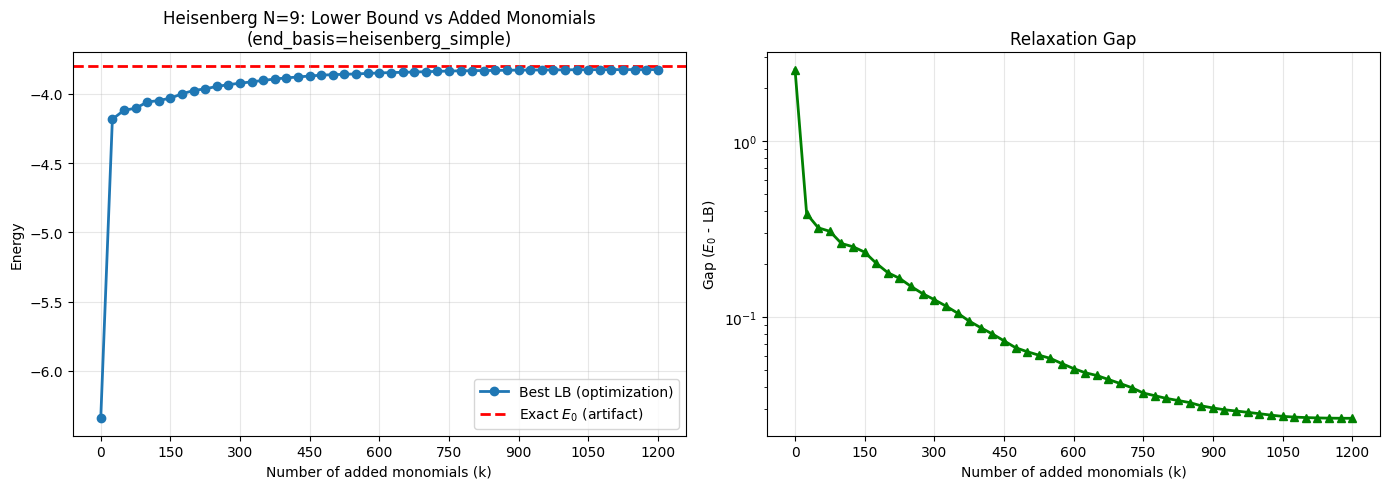

Adding set size (L): 1296


In [22]:
# Plot optimization sweep results
# The function automatically finds the exact ground state energy for comparison
from plots import plot_optimization_sweep

result = plot_optimization_sweep(
    run_hash='5b84c16e059b17e5',
    # model="heisenberg",
    # N=10,
    # boundary="periodic",
    # start_level=1,
    # end_basis="heisenberg_simple",
    # method="pt",
    show_seeds=True,  # Show individual seed results as scatter points
)

print(f"Adding set size (L): {result['L']}")

### Convergence Analysis

How quickly does the lower bound approach the full relaxation value as we add monomials?

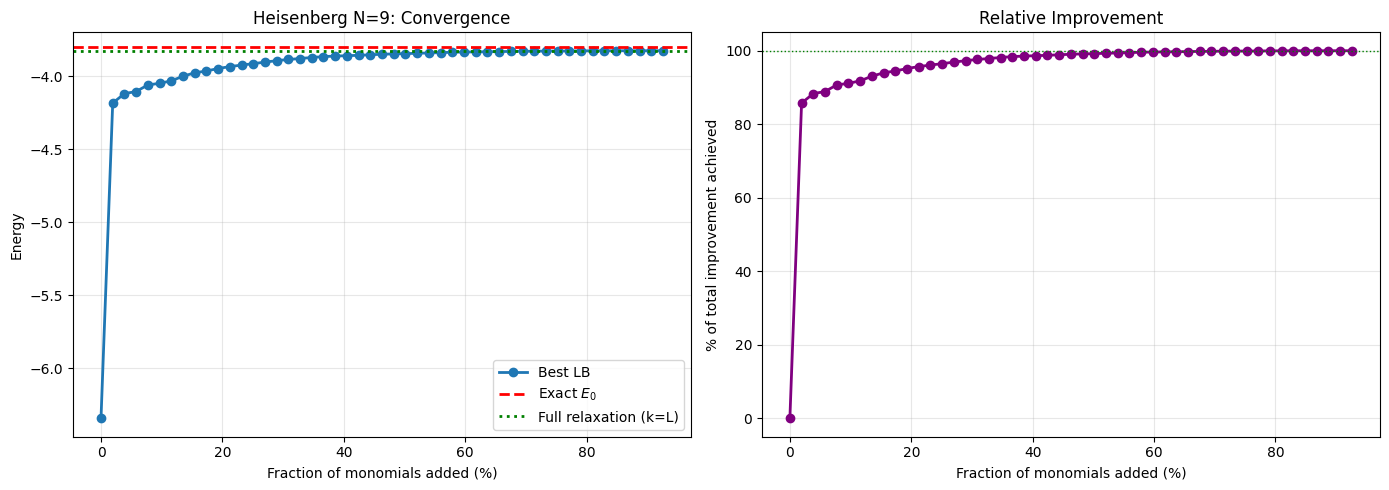


────────────────────────────────────────────────────────────────────────
  Gap to full relaxation  (E_full = -3.82374228)
────────────────────────────────────────────────────────────────────────
       Threshold       k    % of L       Energy LB         Error
  ──────────────  ──────  ────────  ──────────────  ────────────
          ≤ 1e+0      25      1.9%     -4.18254638      3.59e-01
          ≤ 1e-1     300     23.1%     -3.92234450      9.86e-02
          ≤ 1e-2     775     59.8%     -3.83283675      9.09e-03
          ≤ 1e-3    1050     81.0%     -3.82442247      6.80e-04
          ≤ 1e-4    1150     88.7%     -3.82378931      4.70e-05
          ≤ 1e-5    1175     90.7%     -3.82374924      6.96e-06
          ≤ 1e-6    1200     92.6%     -3.82374228     -1.86e-10
          ≤ 1e-7    1200     92.6%     -3.82374228     -1.86e-10
          ≤ 1e-8    1200     92.6%     -3.82374228     -1.86e-10
          ≤ 1e-9    1200     92.6%     -3.82374228     -1.86e-10
         ≤ 1e-10    1200

In [ ]:
# Plot convergence: normalized improvement vs fraction of monomials
from plots import plot_optimization_convergence

_ = plot_optimization_convergence(
    model="heisenberg",
    N=9,
    boundary="periodic",
    start_level=1,
    #end_level=4,
    end_basis="heisenberg_simple",
    method="pt",
)

### Seed Variability Analysis

Compare optimization results across different random seeds to understand reliability.

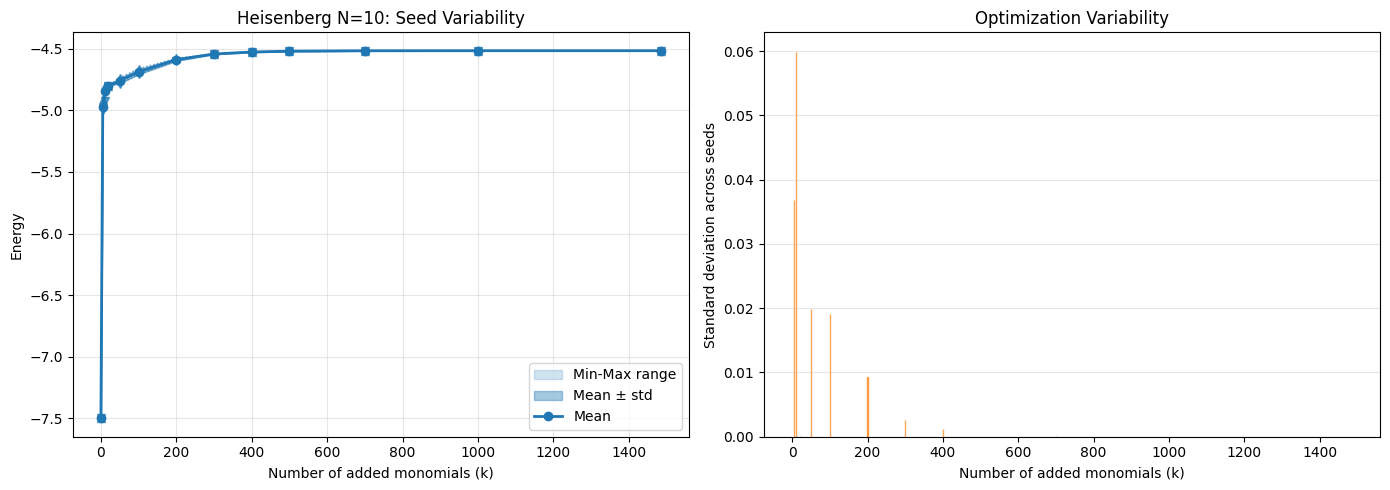

In [16]:
# Plot seed comparison: mean ± std and variability across seeds
from plots import plot_optimization_seeds_comparison

_ = plot_optimization_seeds_comparison(
    model="heisenberg",
    N=10,
    boundary="periodic",
    start_level=1,
    end_level=2,
    end_basis="heisenberg_simple",
    method="pt",
)

### Random Sampling Baseline

To validate that the optimization is actually finding better solutions than random chance, we run a **random sampling baseline**. This picks k monomials randomly (without any optimization) and evaluates the SDP.

#### Running Random Sampling

```bash
# Run random sampling with the same settings as optimization
python -m spins_sdp.scripts.optimization_sweep \
    --model heisenberg --N 4 --boundary periodic \
    --start-level 1 --end-level 2 \
    --method random \
    --k-max 16 --num-seeds 10
```

The random baseline uses `--method random` and evaluates each random selection once (no optimization steps).

In [26]:
# Run random sampling baseline with all symmetries
from spins_sdp.scripts import optimization_sweep

optimization_sweep.main([
    "--model", "heisenberg",
    "--N", "9",
    "--boundary", "periodic",
    "--start-level", "1",
    #"--end-level", "4",
    "--end-basis", "heisenberg_simple",
    "--method", "random",  # Random sampling
    "--ks", "0", "5",
    "10",
    "20",
    "50",
    "100",
    "200",
    "300",
    "400",
    "500",
    "700",
    "1000",
    "1200",
    "1485",
    
    # "10", "20", "40", "80", "100", "150", "200", "250", "300", "350", "400",
    "--num-seeds", "10",   # More seeds for statistical power
    "--resume",
    "--use-all-symmetries",  # Use all symmetries for Heisenberg
])

Model: heisenberg, N=9, boundary=periodic, end_basis=heisenberg_simple
Starting set size: 28, Adding set size: 1296, Final set size: 1324
Total jobs requested: 140, Already in artifact: 130, To compute now: 10


Optimization sweep:   0%|          | 0/10 [00:00<?, ?it/s, k=1200, seed=42]

Optimization sweep: 100%|██████████| 10/10 [00:58<00:00,  5.86s/it, k=1200, seed=51]


Results saved to: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/spins_sdp/results/spin_optimization_sweep/v1/302f87f80177e1c3
Total runs in artifact: 140 (requested this call: 140, computed this call: 10)
Results saved to: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/spins_sdp/results/spin_optimization_sweep/v1/302f87f80177e1c3


0

### Optimization vs Random Comparison

**Is optimization actually finding better solutions than random sampling?**

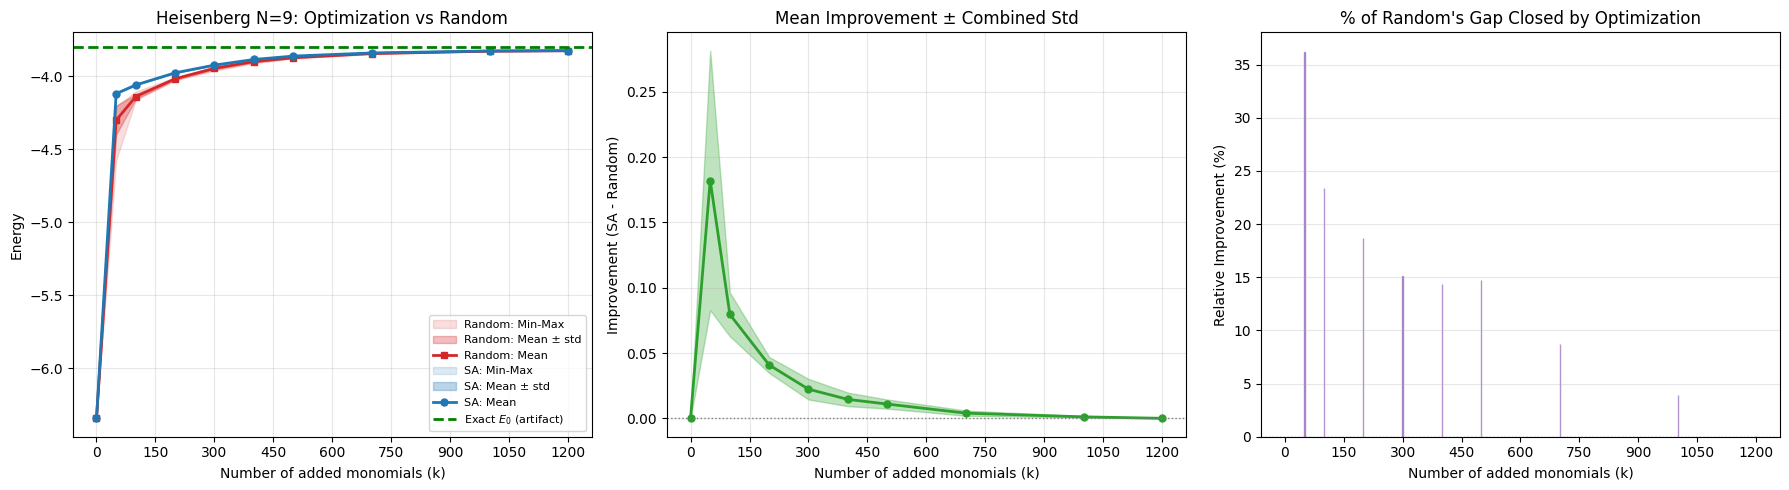

In [27]:
# Compare optimization vs random sampling
from plots import plot_optimization_vs_random

# comparison = plot_optimization_vs_random(
#     model="heisenberg",
#     N=9,
#     boundary="periodic",
#     start_level=1,
#     #end_level=4,
#     end_basis="heisenberg_simple",
#     optimization_method="pt",  # Compare RBM optimization vs random
# )

comparison = plot_optimization_vs_random(opt_run_hash="5b84c16e059b17e5", random_run_hash="302f87f80177e1c3")

### Multi-Method Comparison

When we have multiple optimization methods (SA, PT, BO) plus random sampling, we can compare them all at once:

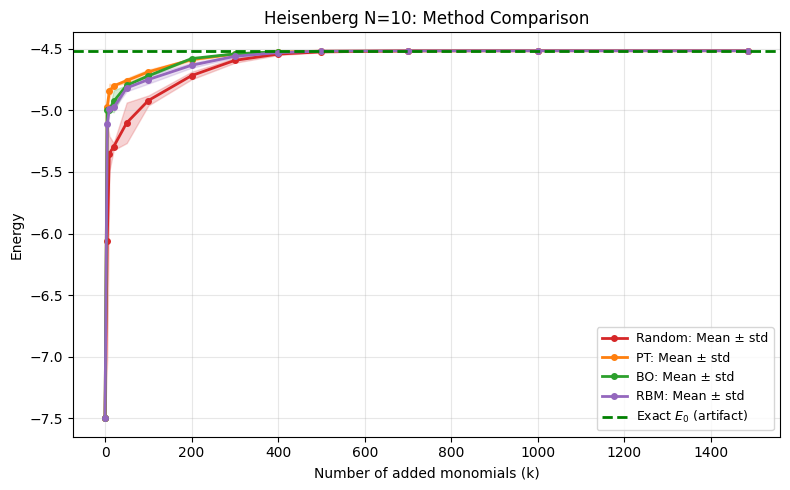

Methods compared: ['random', 'pt', 'bo', 'rbm']


In [10]:
# Compare all available methods
from plots import plot_method_comparison

try:
    method_comparison = plot_method_comparison(
        model="heisenberg",
        N=10,
        boundary="periodic",
        start_level=1,
        end_basis="heisenberg_simple",
        methods=["random", "pt", "bo", "rbm"],  # Will skip methods without data
    )
    print(f"Methods compared: {method_comparison['methods']}")
except FileNotFoundError as e:
    print(f"Note: {e}")
    print("Run more optimization methods to see a full comparison.")

### Timing Analysis

How long does each optimization take?

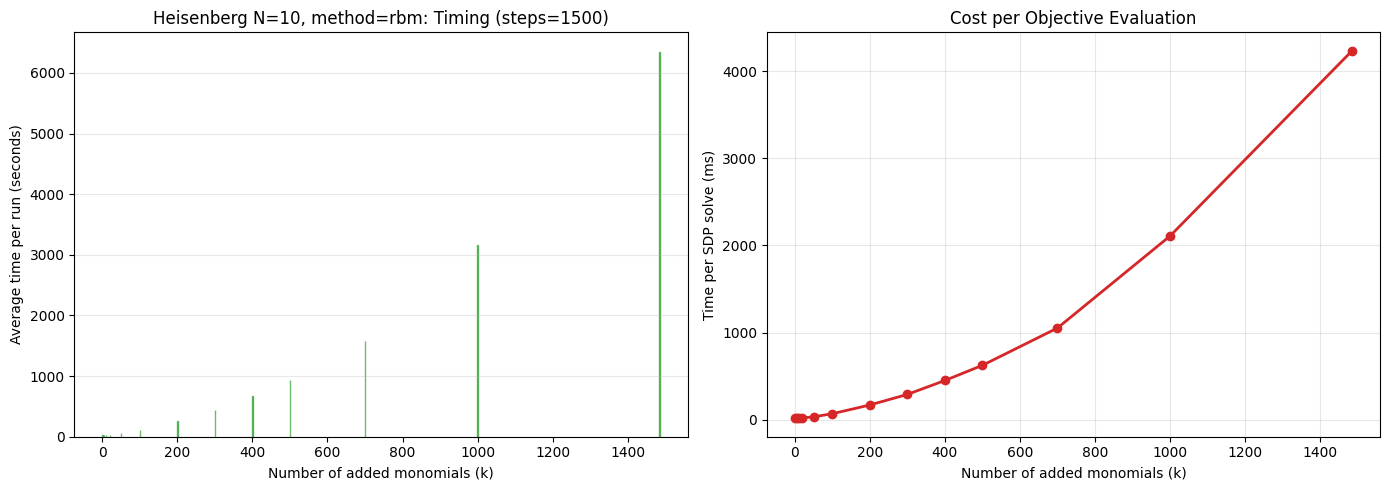

In [1]:
# Plot timing information
from plots import plot_optimization_timing

_ = plot_optimization_timing(
    model="heisenberg",
    N=10,
    boundary="periodic",
    start_level=1,
    end_basis="heisenberg_simple",
    method="rbm",
)

In [4]:
from pathlib import Path
from spins_sdp.scripts.optimization_sweep import get_best_per_k

# Accepts either Path or string, but Path keeps things explicit.
# Note: optimization artifacts live under spins_sdp/results/ by default.
best_by_k = get_best_per_k(Path('spins_sdp/results/spin_optimization_sweep/v1/1404ded0920fe552'))

# Show a quick summary
print(f"Loaded {len(best_by_k)} k-values")
print(f"Largest k present: {max(best_by_k) if best_by_k else None}")

for k, result in best_by_k.items():
    print(result)

Loaded 13 k-values
Largest k present: 1485
{'best_value': -7.499999999999913, 'seed': 42, 'mask': array([False, False, False, ..., False, False, False], shape=(1485,)), 'run_idx': 0}
{'best_value': -4.918657185966291, 'seed': 44, 'mask': array([False, False, False, ..., False, False, False], shape=(1485,)), 'run_idx': 5}
{'best_value': -4.800425590267668, 'seed': 42, 'mask': array([False, False, False, ..., False, False, False], shape=(1485,)), 'run_idx': 6}
{'best_value': -4.800347865247006, 'seed': 44, 'mask': array([False, False, False, ..., False, False, False], shape=(1485,)), 'run_idx': 11}
{'best_value': -4.734913955435727, 'seed': 43, 'mask': array([False, False, False, ..., False, False, False], shape=(1485,)), 'run_idx': 13}
{'best_value': -4.661617776530358, 'seed': 44, 'mask': array([False, False, False, ..., False,  True, False], shape=(1485,)), 'run_idx': 17}
{'best_value': -4.5771485684064706, 'seed': 42, 'mask': array([ True, False, False, ..., False, False, False], sha

## Basis Optimality: heisenberg_simple vs NPA-4 optimised subset (N = 9)

Does the much larger NPA level-4 search space contain a subset **of the same size** as `heisenberg_simple` that produces a tighter SDP bound?

- **Left**: raw convergence — energy vs total basis size.
- **Centre**: normalised — x-axis is % of |heisenberg_simple|; the ★ marks the NPA-4 bound at exactly 100 %.
- **Right**: time efficiency — same energy curves plotted against wall-clock time.

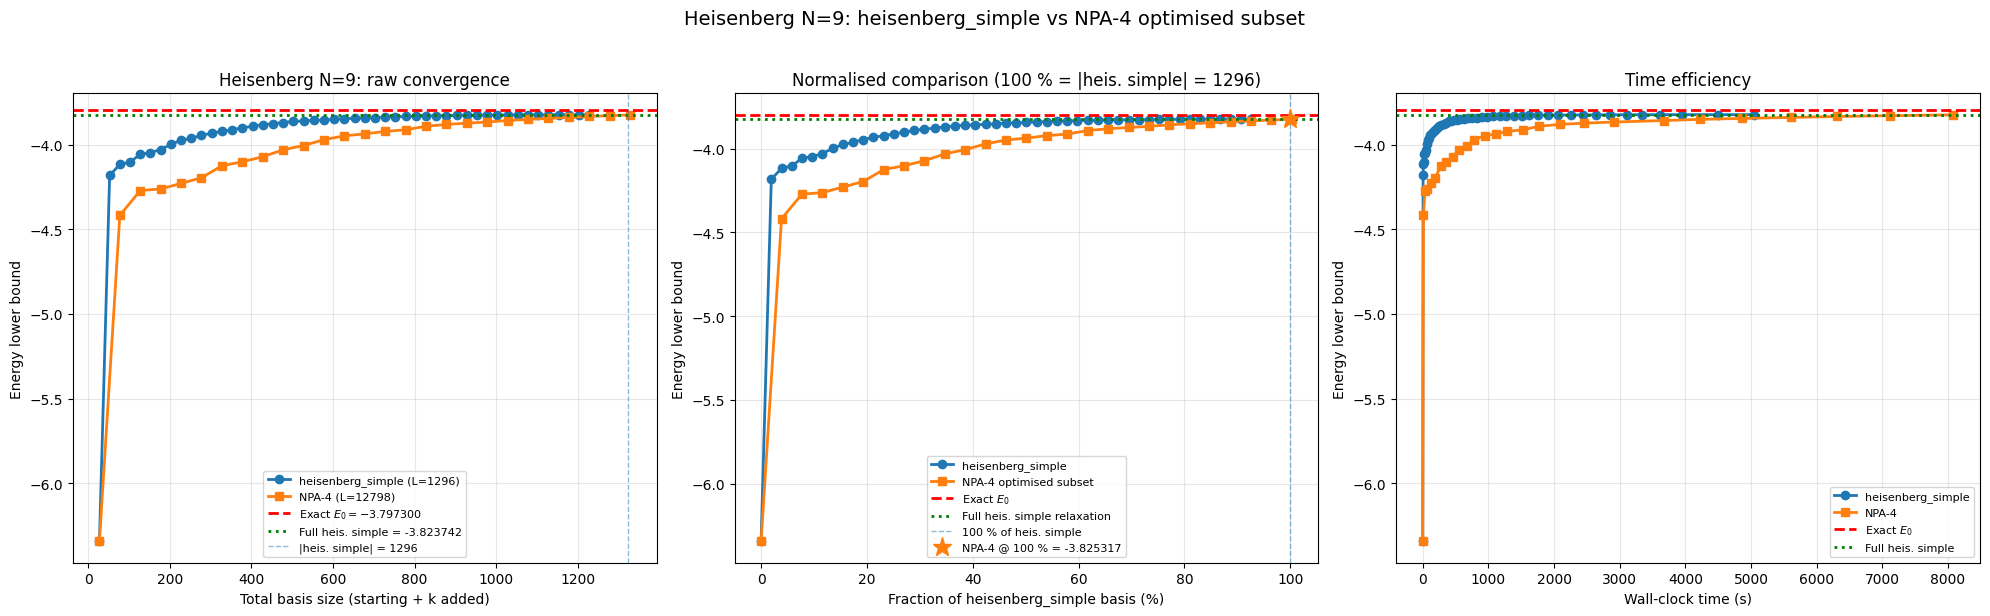


  Basis optimality comparison – Heisenberg N=9
  Exact E₀             : -3.79729978
  Full heis. simple LB  : -3.82374228
  Best heis. sweep      : -3.82374228  (k=1200)
  Best NPA-4 sweep      : -3.82494191  (k=1300)
  NPA-4 @ k=L_heis      : -3.82531739
  Gap (heis full – NPA@L): +0.00157511  (heis tighter)
  |heis full – exact|   : 0.02644250
  |NPA@L – exact|       : 0.02801761
  NPA-4 ever beats heis : No
  |heis. simple| (L)    : 1296
  |NPA-4 adding set|    : 12798



In [ ]:
from plots import plot_basis_optimality_comparison

result = plot_basis_optimality_comparison(
    heis_run_hash="5b84c16e059b17e5",   # heisenberg_simple ending set, N=9
    npa_run_hash="df5c0b3f90521a39",     # NPA level-4 ending set, N=9
)

## Optimization Sweep Summary

The general workflow:

1. **Run Sweep** – Use `optimization_sweep` script or `compute_and_save()` function
   - Supports multiple methods:
     - `--method sa` – Simulated annealing
     - `--method pt` – Parallel tempering
     - `--method bo` – Bayesian optimization
     - `--method rbm` – RBM-based REINFORCE optimization
     - `--method random` – Random sampling baseline
   - Results are saved incrementally with `--resume` support
   - Stores selected monomials as bit-packed masks

2. **List Runs** – Use `list_optimization_runs()` to see available sweeps
   - Filter by model or method: `list_optimization_runs(method="sa")`

3. **Visualize** – Multiple plotting functions:
   - `plot_optimization_sweep()` – Main plot: LB vs k with exact energy reference
   - `plot_optimization_convergence()` – How quickly does the LB converge?
   - `plot_optimization_seeds_comparison()` – Variability across seeds
   - `plot_optimization_timing()` – Timing analysis
   - **`plot_optimization_vs_random()`** – Compare optimization vs random baseline
   - **`plot_method_comparison()`** – Compare multiple methods side-by-side

4. **Load Data** – For custom analysis:
   - `results_to_dataframe()` – Get pandas DataFrame
   - `get_best_per_k()` – Get best result per k value
   - `load_optimization_results()` – Get full data including masks

---

# DMRG Upper Bounds

The `dmrg` script runs DMRG for multiple system sizes, saving results to disk with the same artifact-based pattern as the other scripts.

**Note:** DMRG with PBC requires **N ≥ 4**. Smaller systems will be automatically skipped.

### CLI Usage

```bash
# Heisenberg model
python -m spins_sdp.scripts.dmrg \
    --model heisenberg --N-min 4 --N-max 16 \
    --chi-max 256 --mixer --resume

# Ising model
python -m spins_sdp.scripts.dmrg \
    --model ising --Ns 6 8 10 12 \
    --J 1.0 --h 0.5 \
    --chi-max 128 --mixer --resume

# Heisenberg-J2 model
python -m spins_sdp.scripts.dmrg \
    --model heisenberg_j2 --Ns 8 10 12 \
    --J2 0.5 --chi-max 512 --mixer --resume
```

### Programmatic Usage (in notebook)

In [16]:
# Note: DMRG with PBC requires N >= 4 (two-site update constraint)
from spins_sdp.scripts import dmrg

# Run DMRG for Heisenberg model
dmrg.main([
    "--model", "heisenberg",
    "--N-min", "4",
    "--N-max", "10",
    "--chi-max", "128",
    "--mixer",
    "--resume",
])

ModuleNotFoundError: No module named 'tenpy'

`list_dmrg_runs()` to see what DMRG results are stored.

In [4]:
from spins_sdp.scripts.dmrg import list_dmrg_runs

runs = list_dmrg_runs()
print(f"Found {len(runs)} DMRG run(s):\n")
for run in runs:
    print(f"  Model: {run['model']}, chi_max={run['chi_max']}, mixer={run['mixer']}")
    print(f"  N values: {run.get('Ns_present', [])}")
    print(f"  Path: {run['_run_dir']}")
    print()

Found 2 DMRG run(s):

  Model: heisenberg, chi_max=128, mixer=True
  N values: [4, 5, 6, 7, 8, 9, 10]
  Path: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_dmrg_energy_ub\v1\d6a08aa1f18196a6

  Model: heisenberg, chi_max=64, mixer=True
  N values: []
  Path: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_dmrg_energy_ub\v1\e8570fa916ecad9d



Load DMRG results for custom analysis.

In [5]:
# Load DMRG results from the most recent run
from spins_sdp.scripts.dmrg import load_dmrg_results
from pathlib import Path

run_root = Path("spins_sdp/results/spin_dmrg_energy_ub/v1")
if run_root.exists():
    run_dirs = sorted([d for d in run_root.iterdir() if d.is_dir()], 
                      key=lambda d: d.stat().st_mtime, reverse=True)
    if run_dirs:
        run_dir = run_dirs[0]
        results = load_dmrg_results(run_dir)
        
        print("DMRG Results:")
        print(f"Model: {results['meta']['model']}")
        print(f"chi_max: {results['meta']['chi_max']}, mixer: {results['meta']['mixer']}")
        print()
        print(f"{'N':>4} {'E (total)':>14} {'e (per site)':>14} {'chi_final':>10} {'time (s)':>10}")
        print("-" * 56)
        for N in sorted(results['data'].keys()):
            d = results['data'][N]
            print(f"{N:4d} {d['E']:14.8f} {d['e']:14.8f} {d['chi_final']:10d} {d['elapsed_s']:10.2f}")
else:
    print("No DMRG runs found. Run the cell above first.")

DMRG Results:
Model: heisenberg
chi_max: 128, mixer: True

   N      E (total)   e (per site)  chi_final   time (s)
--------------------------------------------------------
   4    -2.00000000    -0.50000000          4       0.10
   5    -1.86803399    -0.37360680          4       0.90
   6    -2.80277564    -0.46712927          8       0.21
   7    -2.85517926    -0.40788275          8      47.22
   8    -3.65109341    -0.45638668         16       0.35
   9    -3.79729978    -0.42192220         16       0.60
  10    -4.51544635    -0.45154464         32       0.52


## Certifying Observable Bounds from Energy Bounds

Given certified bounds $E_L \leq E_0 \leq E_U$, the SDP relaxation can also bound the expectation value of **any** observable $O$ in the ground state:

$$\min / \max \; \mathrm{tr}(O \cdot \Gamma) \quad \text{s.t.} \quad \Gamma \succeq 0,\; \langle I \rangle = 1,\; E_L \leq \langle H \rangle \leq E_U$$

We test this on the Heisenberg chain (N=6) where exact diagonalisation is fast, bounding several observables:
- Nearest-neighbour ZZ correlation $\langle Z_0 Z_1 \rangle$
- Average NN correlation $\frac{1}{N}\sum \sigma_i^z \sigma_{i+1}^z$
- Staggered magnetization

In [ ]:
import numpy as np
import qutip as qt

from spins_sdp.sdp import bound_observable, solve_pauli_relaxation
from spins_sdp.models import (
    heisenberg_hamiltonian_dict,
    heisenberg_hamiltonian_exact,
    two_point_correlation_dict,
    nearest_neighbor_correlation_dict,
    staggered_magnetization_z_dict,
)
from spins_sdp.basis_builder import generate_heisenberg_paper_basis
from spins_sdp.symmetry import SymmetryManager

# --- Setup: Heisenberg N=6 ---
N = 6
boundary = "periodic"
H_dict = heisenberg_hamiltonian_dict(N, boundary=boundary)
H_exact = heisenberg_hamiltonian_exact(N, boundary=boundary)
basis = generate_heisenberg_paper_basis(N)
sym = SymmetryManager.default_for_heisenberg(N)

# Exact ground state (get a few eigenvalues to detect degeneracy)
n_eig = min(6, 2**N)
evals, evecs = H_exact.eigenstates(eigvals=n_eig)
E0 = float(evals[0])
# Collect all degenerate ground states (within tolerance)
gs_indices = [i for i in range(len(evals)) if abs(evals[i] - E0) < 1e-10]
gs_states = [evecs[i] for i in gs_indices]
gs_degeneracy = len(gs_states)
print(f"Exact ground-state energy E₀ = {E0:.10f}  (degeneracy = {gs_degeneracy})")

# SDP lower bound (moment relaxation)
E_sdp = solve_pauli_relaxation(basis, H_dict, sym, sense="min")
print(f"SDP lower bound           E_L = {E_sdp:.10f}")
print(f"Gap E₀ − E_L              = {E0 - E_sdp:.2e}")

# Ensure E_L <= E₀ (may be slightly violated due to solver tolerance)
E_L = min(E_sdp, E0)

# --- Define observables to bound ---
observables = {
    "⟨Z₀Z₁⟩": two_point_correlation_dict(N, 0, 1, axis="z"),
    "avg ⟨ZᵢZᵢ₊₁⟩": nearest_neighbor_correlation_dict(N, axis="z", boundary=boundary),
    "stag. mag. z": staggered_magnetization_z_dict(N),
}

# Exact expectation values: average over degenerate ground states
# (= trace over ground-state projector / degeneracy).
# The SDP with sign symmetry produces bounds valid for this isotropic average.
def exact_expectation_gs_avg(gs_states, op_dict, N):
    """Compute Tr(O · P_GS) / deg from an Operator dict."""
    total = 0.0
    for psi in gs_states:
        for w, c in op_dict.items():
            ops = [qt.qeye(2)] * N
            for site in range(N):
                xbit = (w.x_mask >> site) & 1
                zbit = (w.z_mask >> site) & 1
                if (xbit, zbit) == (1, 0):
                    ops[site] = qt.sigmax()
                elif (xbit, zbit) == (0, 1):
                    ops[site] = qt.sigmaz()
                elif (xbit, zbit) == (1, 1):
                    ops[site] = qt.sigmay()
            total += c * qt.expect(qt.tensor(ops), psi)
    return float(np.real(total)) / len(gs_states)

# --- Compute bounds with two energy windows ---
print(f"\n{'='*80}")
print(f"  Observable bounds for Heisenberg N={N} (periodic)")
print(f"{'='*80}")
print(f"  E₀ (exact) = {E0:.10f},  E_SDP (LB) = {E_sdp:.10f}")
if gs_degeneracy > 1:
    print(f"  NOTE: Ground state is {gs_degeneracy}-fold degenerate.")
    print(f"        'Exact' column shows the isotropic average over the manifold.")

# Window 1: E_L = SDP lower bound, E_U = exact E₀
# Window 2: E_L = E_U = E₀ (exact energy → tightest possible)
for label, e_lb, e_ub in [
    ("Window 1: [E_SDP, E₀]", E_L,  E0),
    ("Window 2: [E₀, E₀]   ", E0,   E0),
]:
    print(f"\n  --- {label}  [{e_lb:.6f}, {e_ub:.6f}] ---")
    print(f"  {'Observable':<20} {'Exact':>10} {'SDP LB':>10} {'SDP UB':>10} {'Width':>10}")
    print(f"  {'─'*20} {'─'*10} {'─'*10} {'─'*10} {'─'*10}")
    for name, obs_dict in observables.items():
        exact_val = exact_expectation_gs_avg(gs_states, obs_dict, N)
        result = bound_observable(
            basis=basis,
            hamiltonian=H_dict,
            observable=obs_dict,
            energy_lb=e_lb,
            energy_ub=e_ub,
            symmetry_manager=sym,
            mosek_tol=1e-7,
        )
        width = result.ub - result.lb
        print(
            f"  {name:<20} {exact_val:>10.6f} {result.lb:>10.6f} "
            f"{result.ub:>10.6f} {width:>10.2e}"
        )
        # Sanity check: exact value should be within the certified bounds
        assert result.lb - 1e-4 <= exact_val <= result.ub + 1e-4, (
            f"FAIL: exact {exact_val} not in [{result.lb}, {result.ub}]"
        )
    print("  ✓ All exact values within certified bounds")

Exact ground-state energy E₀ = -2.8027756377  (degeneracy = 1)
SDP lower bound           E_L = -2.8027729879
Gap E₀ − E_L              = -2.65e-06

  Observable bounds for Heisenberg N=6 (periodic)
  E₀ (exact) = -2.8027756377,  E_SDP (LB) = -2.8027729879

  --- Window 1: [E_SDP, E₀]  [-2.802776, -2.802776] ---
  Observable                Exact     SDP LB     SDP UB      Width
  ──────────────────── ────────── ────────── ────────── ──────────
  ⟨Z₀Z₁⟩                -0.622839  -0.622841  -0.622831   9.84e-06
  avg ⟨ZᵢZᵢ₊₁⟩          -0.622839  -0.622840  -0.622824   1.61e-05
  stag. mag. z          -0.000000   0.000000   0.000000   0.00e+00
  ✓ All exact values within certified bounds

  --- Window 2: [E₀, E₀]     [-2.802776, -2.802776] ---
  Observable                Exact     SDP LB     SDP UB      Width
  ──────────────────── ────────── ────────── ────────── ──────────
  ⟨Z₀Z₁⟩                -0.622839  -0.622841  -0.622831   9.84e-06
  avg ⟨ZᵢZᵢ₊₁⟩          -0.622839  -0.622840  -0.

## Fixed-Fraction Scaling: How Does the Gap Scale with N?

Given a fraction $p \in [0, 1]$, for each system size $N$ we:
1. Build the full basis (starting set + adding set of size $L$).
2. Compute the **full relaxation** $E_{\text{full}}$ using all $L$ monomials.
3. Run optimisation (e.g. parallel tempering) to select $k = \lfloor p \cdot L \rfloor$ monomials → $E_{\text{partial}}$.
4. Record the gap $|E_{\text{full}} - E_{\text{partial}}|$.

Sweeping $N$ reveals how the partial-relaxation quality scales with system size.

### CLI Usage

```bash
python -m spins_sdp.scripts.fraction_scaling \
    --model heisenberg --N-min 4 --N-max 14 \
    --fraction 0.5 --method pt --pt-epochs 5 \
    --num-seeds 3 --use-all-symmetries

# Or with explicit N values and seeds
python -m spins_sdp.scripts.fraction_scaling \
    --model heisenberg --Ns 4 6 8 10 12 \
    --fraction 0.3 --method pt --seeds 42 43 44 \
    --use-all-symmetries
```

### Programmatic Usage

In [42]:
# Compute fraction-scaling data for a small test case
from spins_sdp.scripts import fraction_scaling

fraction_scaling.main([
    "--model", "heisenberg",
    "--Ns", "4", "5", "6", "7", "8", "9", "10", 
    "--boundary", "periodic",
    "--start-level", "1",
    "--end-basis", "heisenberg_simple",
    "--fraction", "0.5",
    "--method", "pt",
    "--pt-epochs", "1",
    "--pt-steps-per-epoch", "10",
    "--num-seeds", "1",
    "--use-all-symmetries",
    "--resume",
])

Fraction scaling: p=0.5, method=pt
  Model: heisenberg, boundary=periodic, end_basis=heisenberg_simple, start_level=1
  N values: [4, 5, 6, 7, 8, 9, 10], seeds: [42]
  Total jobs: 7, cached: 6, to compute: 4


Fraction scaling:   0%|          | 0/4 [00:00<?, ?it/s, N=5, seed=42]

  N=5: L=630, k=315, E_full=-1.8680339886 (0.4s)


Fraction scaling:  25%|██▌       | 1/4 [00:09<00:21,  7.31s/it, N=7, seed=42]

  N=7: L=945, k=472, E_full=-2.8551792567 (2.1s)


...

Fraction scaling:  75%|███████▌  | 3/4 [02:39<01:01, 61.59s/it, N=10, seed=42]

  N=10: L=1485, k=742, E_full=-4.5154464270 (11.5s)


Fraction scaling: 100%|██████████| 4/4 [05:36<00:00, 84.25s/it, N=10, seed=42] 


Results saved to: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/spins_sdp/results/spin_fraction_scaling/v1/2b9d41bd28e41433
Results saved to: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/spins_sdp/results/spin_fraction_scaling/v1/2b9d41bd28e41433


0

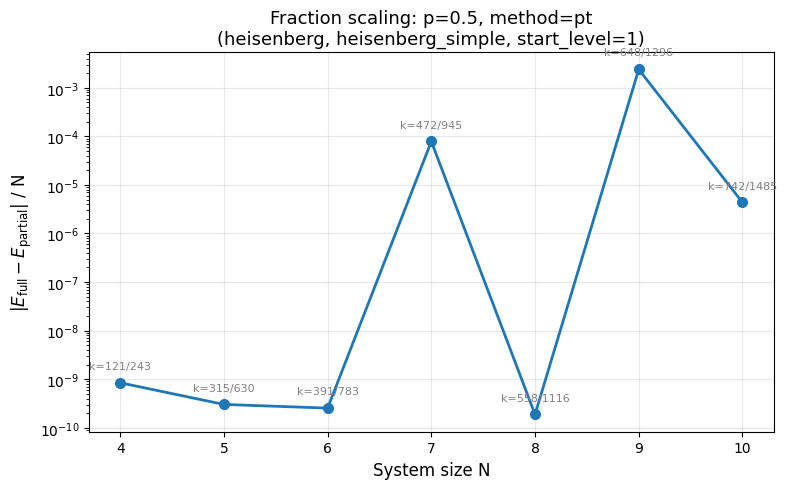


   N      L      k    k/L         E_full      E_partial        |Gap|      |Gap|/N
----------------------------------------------------------------------------------
   4    243    121   0.50    -2.00000000    -2.00000000     3.38e-09     8.44e-10
   5    630    315   0.50    -1.86803399    -1.86803399     1.51e-09     3.02e-10
   6    783    391   0.50    -2.80277564    -2.80277563     1.53e-09     2.54e-10
   7    945    472   0.50    -2.85517926    -2.85572887     5.50e-04     7.85e-05
   8   1116    558   0.50    -3.65109341    -3.65109341     1.50e-09     1.88e-10
   9   1296    648   0.50    -3.82374228    -3.84524990     2.15e-02     2.39e-03
  10   1485    742   0.50    -4.51544643    -4.51549009     4.37e-05     4.37e-06


: 

In [ ]:
# Plot the fraction-scaling results (with per-site error)
from plots import plot_fraction_scaling

_ = plot_fraction_scaling(
    model="heisenberg",
    boundary="periodic",
    model_params={},
    start_level=1,
    end_basis="heisenberg_simple",
    fraction=0.5,
    method="pt",
    per_site=True,   # Show |Gap|/N
)

### Overnight Run: Comparing Multiple Fractions

To produce publication-quality scaling curves we run **three fractions**
(p=0.3, 0.5, 0.7) overnight on separate machines, each pushing to high N.

Each script uses **two phases** (same config hash → one artifact):
- **Phase 1**: small N with 3 seeds (statistical quality)
- **Phase 2**: large N with 1 seed (maximum reach)

PT config: 8 chains, 1 epoch, 15 steps → 128 SDP evals/seed.

| Machine | Script | p | N range | Seeds | Est. time |
|---|---|---|---|---|---|
| 1 | `overnight_machine1_p03.sh` | 0.3 | 4–20 | 3 (N≤12), 1 (N≥13) | ~9 hrs |
| 2 | `overnight_machine2_p05.sh` | 0.5 | 4–18 | 3 (N≤12), 1 (N≥13) | ~7.5 hrs |
| 3 | `overnight_machine3_p07.sh` | 0.7 | 4–16 | 3 (N≤10), 1 (N≥11) | ~7.6 hrs |

```bash
# On each machine:
bash spins_sdp/run/overnight_machine1_p03.sh   # Machine 1
bash spins_sdp/run/overnight_machine2_p05.sh   # Machine 2
bash spins_sdp/run/overnight_machine3_p07.sh   # Machine 3
```

After merging the `spins_sdp/results/spin_fraction_scaling/` directories,
use `plot_fraction_scaling_comparison`:

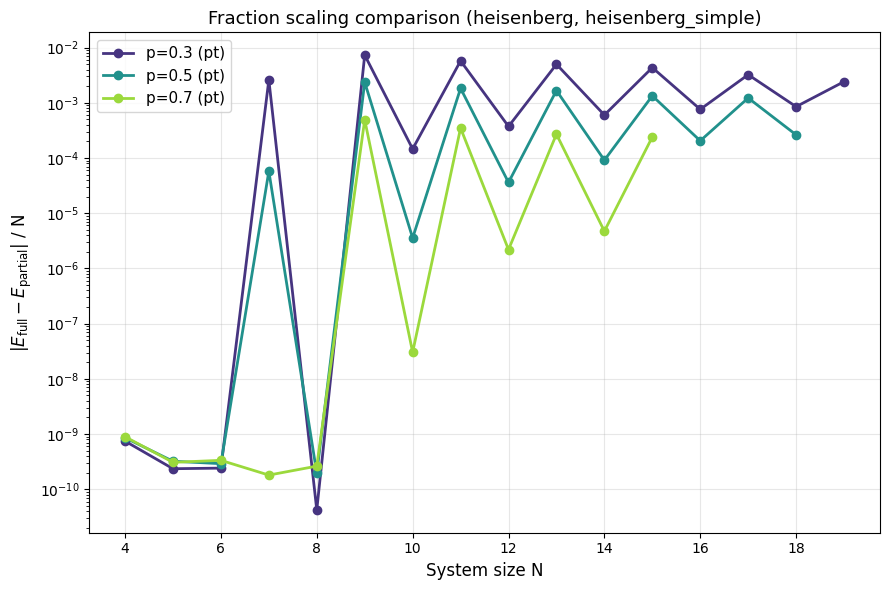


    p    N      L      k    k/L        |Gap|      |Gap|/N
------------------------------------------------------------
 0.30    4    243     72   0.30     2.99e-09     7.46e-10
 0.30    5    630    189   0.30     1.18e-09     2.36e-10
 0.30    6    783    234   0.30     1.45e-09     2.42e-10
 0.30    7    945    283   0.30     1.82e-02     2.61e-03
 0.30    8   1116    334   0.30     3.38e-10     4.22e-11
 0.30    9   1296    388   0.30     6.59e-02     7.32e-03
 0.30   10   1485    445   0.30     1.46e-03     1.46e-04
 0.30   11   1683    504   0.30     6.33e-02     5.75e-03
 0.30   12   1890    567   0.30     4.48e-03     3.73e-04
 0.30   13   2106    631   0.30     6.49e-02     4.99e-03
 0.30   14   2331    699   0.30     8.41e-03     6.01e-04
 0.30   15   2565    769   0.30     6.51e-02     4.34e-03
 0.30   16   2808    842   0.30     1.22e-02     7.61e-04
 0.30   17   3060    918   0.30     5.49e-02     3.23e-03
 0.30   18   3321    996   0.30     1.53e-02     8.51e-04
 0.30   19

In [1]:
# Compare fraction-scaling results across p=0.3, 0.5, 0.7
# (Run this after the overnight scripts have completed and results are merged)
from plots import plot_fraction_scaling_comparison

_ = plot_fraction_scaling_comparison(
    fractions=[0.3, 0.5, 0.7],
    model="heisenberg",
    boundary="periodic",
    model_params={},
    start_level=1,
    end_basis="heisenberg_simple",
    methods="pt",
    per_site=True,   # Gap per spin
)